# Student Success Early-Warning Analysis

## Project objective

This project investigates whether machine-learning models can identify students at risk of dropout or unsuccessful academic outcomes using enrolment, early academic and online-learning information.

The analysis is framed as an early-warning decision-support system. Predictions should be used to offer appropriate support to students and should not automatically determine interventions.

## Research questions

1. Can Decision Tree and Random Forest classifiers identify students at risk using information available early enough for intervention?
2. Do student background and early academic attributes or online-engagement behaviour provide stronger early-warning signals?
3. Are the insights from the two datasets complementary or contradictory?

## Reproducibility

All modelling uses `random_state=42`. The two datasets are analysed separately because they come from different institutions and use different structures and outcome definitions.

In [1]:
from pathlib import Path
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")

print("Python:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 3.0.5
NumPy: 2.5.1
scikit-learn: 1.9.0


In [2]:
# Locate the project root whether the notebook starts in the project
# directory or inside the notebooks directory.
current_directory = Path.cwd().resolve()

if (current_directory / "data" / "raw").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "data" / "raw").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Could not locate data/raw. Open the notebook from the project folder."
    )

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
DROPOUT_PATH = RAW_DATA_DIR / "dropout" / "data.csv"
OULAD_DIR = RAW_DATA_DIR / "oulad"

FILE_PATHS = {
    "dropout": DROPOUT_PATH,
    "assessments": OULAD_DIR / "assessments.csv",
    "courses": OULAD_DIR / "courses.csv",
    "studentAssessment": OULAD_DIR / "studentAssessment.csv",
    "studentInfo": OULAD_DIR / "studentInfo.csv",
    "studentRegistration": OULAD_DIR / "studentRegistration.csv",
    "studentVle": OULAD_DIR / "studentVle.csv",
    "vle": OULAD_DIR / "vle.csv",
}

file_audit = pd.DataFrame(
    [
        {
            "file": name,
            "path": str(path),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024**2), 2)
            if path.exists()
            else np.nan,
        }
        for name, path in FILE_PATHS.items()
    ]
)

display(file_audit)

assert file_audit["exists"].all(), "One or more required dataset files are missing."

print("Project root:", PROJECT_ROOT)
print("All required files were found.")

,file,path,exists,size_mb
0,dropout,C:\Users\fatim\OneDrive\Documents\data science...,True,0.51
1,assessments,C:\Users\fatim\OneDrive\Documents\data science...,True,0.01
2,courses,C:\Users\fatim\OneDrive\Documents\data science...,True,0.00
3,studentAssessment,C:\Users\fatim\OneDrive\Documents\data science...,True,5.43
4,studentInfo,C:\Users\fatim\OneDrive\Documents\data science...,True,3.30
5,studentRegistration,C:\Users\fatim\OneDrive\Documents\data science...,True,1.08
6,studentVle,C:\Users\fatim\OneDrive\Documents\data science...,True,432.81
7,vle,C:\Users\fatim\OneDrive\Documents\data science...,True,0.26


Project root: C:\Users\fatim\OneDrive\Documents\data science
All required files were found.


In [3]:
# The downloaded UCI file uses semicolons as delimiters.
dropout_df = pd.read_csv(DROPOUT_PATH, sep=";")

# Remove accidental whitespace from column names without changing raw data.
dropout_df.columns = dropout_df.columns.str.strip()

print("Dataset shape:", dropout_df.shape)
print("Duplicate rows:", dropout_df.duplicated().sum())
print("\nColumns:")
print(dropout_df.columns.tolist())

display(dropout_df.head())

dropout_missing = (
    dropout_df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

print("\nColumns containing missing values:")
display(dropout_missing[dropout_missing["missing_count"] > 0])

target_distribution = (
    dropout_df["Target"]
    .value_counts(dropna=False)
    .rename_axis("Target")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(dropout_df) * 100
).round(2)

print("\nTarget-class distribution:")
display(target_distribution)

Dataset shape: (4424, 37)
Duplicate rows: 0

Columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment r

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Columns containing missing values:


,missing_count



Target-class distribution:


,Target,count,percentage
0,Graduate,2209,49.93
1,Dropout,1421,32.12
2,Enrolled,794,17.95


In [4]:
# A question mark represents missing information in several OULAD files.
oulad_small_paths = {
    name: path
    for name, path in FILE_PATHS.items()
    if name not in {"dropout", "studentVle"}
}

oulad_tables = {
    name: pd.read_csv(path, na_values=["?"])
    for name, path in oulad_small_paths.items()
}

for table in oulad_tables.values():
    table.columns = table.columns.str.strip()

oulad_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows": table.shape[0],
            "columns": table.shape[1],
            "missing_cells": int(table.isna().sum().sum()),
            "duplicate_rows": int(table.duplicated().sum()),
        }
        for name, table in oulad_tables.items()
    ]
)

display(oulad_summary)

for name, table in oulad_tables.items():
    print(f"\n{name}:")
    print(table.columns.tolist())
    display(table.head(3))

student_info = oulad_tables["studentInfo"]

oulad_outcomes = (
    student_info["final_result"]
    .value_counts(dropna=False)
    .rename_axis("final_result")
    .reset_index(name="count")
)

oulad_outcomes["percentage"] = (
    oulad_outcomes["count"] / len(student_info) * 100
).round(2)

print("\nOriginal OULAD outcome distribution:")
display(oulad_outcomes)

,table,rows,columns,missing_cells,duplicate_rows
0,assessments,206,6,11,0
1,courses,22,3,0,0
2,studentAssessment,173912,5,173,0
3,studentInfo,32593,12,1111,0
4,studentRegistration,32593,5,22566,0
5,vle,6364,6,10486,0



assessments:
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0



courses:
['code_module', 'code_presentation', 'module_presentation_length']


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268


...

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0



vle:
['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN



Original OULAD outcome distribution:


,final_result,count,percentage
0,Pass,12361,37.93
1,Withdrawn,10156,31.16
2,Fail,7052,21.64
3,Distinction,3024,9.28


In [5]:
STUDENT_VLE_PATH = FILE_PATHS["studentVle"]

student_vle_sample = pd.read_csv(
    STUDENT_VLE_PATH,
    na_values=["?"],
    nrows=5,
)

student_vle_sample.columns = student_vle_sample.columns.str.strip()

print("studentVle columns:")
print(student_vle_sample.columns.tolist())

display(student_vle_sample)

# Count rows in chunks without keeping the whole table in memory.
student_vle_row_count = 0

for chunk in pd.read_csv(
    STUDENT_VLE_PATH,
    usecols=["id_student"],
    chunksize=1_000_000,
):
    student_vle_row_count += len(chunk)

print(f"studentVle row count: {student_vle_row_count:,}")

studentVle columns:
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


studentVle row count: 10,655,280


## Target Construction and Leakage Prevention

### Dataset 1: Student Dropout and Academic Success

The original three-class target is retained:

- `Dropout`
- `Enrolled`
- `Graduate`

Keeping `Enrolled` as a separate outcome avoids making the unsupported assumption that students who remain enrolled have already succeeded.

The primary early-warning metric will be recall for the `Dropout` class. Macro F1-score and balanced accuracy will also be used because the three classes are unevenly distributed.

All six second-semester variables are excluded from the main analysis. These variables occur too late to support meaningful early intervention. Enrolment, demographic, socioeconomic and first-semester variables remain available.

### Dataset 2: Open University Learning Analytics Dataset

The original outcomes are transformed into a binary target:

- `At Risk`: `Withdrawn` or `Fail`
- `Successful`: `Pass` or `Distinction`

The prediction point is the end of course day 60. Students who had already unregistered on or before day 60 are excluded because their withdrawal was already known at the prediction point. Including them would not represent a genuine early-warning prediction task.

The following leakage-prevention rules are applied:

- Only VLE interactions from course days 0–60 are used.
- Interactions after day 60 are excluded.
- Assessments must be due by day 60.
- Only submissions available by day 60 are used.
- Students who unregistered on or before day 60 are excluded.
- `final_result` is used only to construct the target.
- `date_unregistration` is used only to define eligibility and is not a predictive feature.
- `id_student` is used only for joining tables and is removed before modelling.

Predictions are intended to support human-led intervention and should not automatically determine decisions about students.

In [6]:
#prepare datatset 1 
DROPOUT_TARGET = "Target"

second_semester_columns = [
    column
    for column in dropout_df.columns
    if "2nd sem" in column
]

print("Second-semester columns excluded:")
for column in second_semester_columns:
    print("-", column)

dropout_model_data = dropout_df.drop(
    columns=second_semester_columns
).copy()

X_dropout_raw = dropout_model_data.drop(
    columns=[DROPOUT_TARGET]
).copy()

y_dropout = dropout_model_data[DROPOUT_TARGET].copy()

dropout_leakage_audit = pd.DataFrame(
    {
        "item": [
            "Original rows",
            "Original predictors",
            "Second-semester predictors excluded",
            "Predictors retained",
            "Target classes",
        ],
        "value": [
            len(dropout_df),
            dropout_df.shape[1] - 1,
            len(second_semester_columns),
            X_dropout_raw.shape[1],
            ", ".join(sorted(y_dropout.unique())),
        ],
    }
)

display(dropout_leakage_audit)

dropout_target_audit = (
    y_dropout.value_counts()
    .rename_axis("Target")
    .reset_index(name="count")
)

dropout_target_audit["percentage"] = (
    dropout_target_audit["count"] / len(y_dropout) * 100
).round(2)

display(dropout_target_audit)

assert len(second_semester_columns) == 6
assert DROPOUT_TARGET not in X_dropout_raw.columns
assert not any("2nd sem" in column for column in X_dropout_raw.columns)

print("Dataset 1 leakage checks passed.")

Second-semester columns excluded:
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)


,item,value
0,Original rows,4424
1,Original predictors,36
2,Second-semester predictors excluded,6
3,Predictors retained,30
4,Target classes,"Dropout, Enrolled, Graduate"


,Target,count,percentage
0,Graduate,2209,49.93
1,Dropout,1421,32.12
2,Enrolled,794,17.95


Dataset 1 leakage checks passed.


In [7]:
#Construct the OULAD day-60 cohort
OULAD_KEYS = [
    "code_module",
    "code_presentation",
    "id_student",
]

EARLY_WINDOW_END = 60

student_info = oulad_tables["studentInfo"].copy()
student_registration = oulad_tables["studentRegistration"].copy()

# Confirm that each student-course record has one row in each table.
student_info_key_duplicates = student_info.duplicated(
    subset=OULAD_KEYS
).sum()

registration_key_duplicates = student_registration.duplicated(
    subset=OULAD_KEYS
).sum()

print("Duplicate studentInfo keys:", student_info_key_duplicates)
print("Duplicate studentRegistration keys:", registration_key_duplicates)

assert student_info_key_duplicates == 0
assert registration_key_duplicates == 0

oulad_base = student_info.merge(
    student_registration[
        OULAD_KEYS
        + [
            "date_registration",
            "date_unregistration",
        ]
    ],
    on=OULAD_KEYS,
    how="left",
    validate="one_to_one",
)

print("Merged OULAD shape:", oulad_base.shape)
display(oulad_base.head())

Duplicate studentInfo keys: 0
Duplicate studentRegistration keys: 0
Merged OULAD shape: (32593, 14)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,-92.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,NaN
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,NaN


In [8]:
#Remove outcomes known by day 60
# A withdrawal on or before day 60 is already known at the
# prediction point and is therefore excluded from the cohort.
known_withdrawal_by_day_60 = (
    oulad_base["date_unregistration"].notna()
    & oulad_base["date_unregistration"].le(EARLY_WINDOW_END)
)

oulad_day60_cohort = oulad_base.loc[
    ~known_withdrawal_by_day_60
].copy()

cohort_audit = pd.DataFrame(
    {
        "cohort_stage": [
            "Original student-course records",
            "Withdrawals already known by day 60",
            "Records eligible for day-60 prediction",
        ],
        "records": [
            len(oulad_base),
            int(known_withdrawal_by_day_60.sum()),
            len(oulad_day60_cohort),
        ],
    }
)

display(cohort_audit)

withdrawal_timing_audit = pd.crosstab(
    oulad_base["final_result"],
    known_withdrawal_by_day_60,
).rename(
    columns={
        False: "eligible_at_day_60",
        True: "outcome_known_by_day_60",
    }
)

display(withdrawal_timing_audit)

assert (
    len(oulad_day60_cohort)
    + known_withdrawal_by_day_60.sum()
    == len(oulad_base)
)

,cohort_stage,records
0,Original student-course records,32593
1,Withdrawals already known by day 60,6232
2,Records eligible for day-60 prediction,26361


date_unregistration,eligible_at_day_60,outcome_known_by_day_60
final_result,,
Distinction,3024,0
Fail,7044,8
Pass,12361,0
Withdrawn,3932,6224


In [9]:
#Construct the binary OULAD target
at_risk_outcomes = {
    "Withdrawn",
    "Fail",
}

successful_outcomes = {
    "Pass",
    "Distinction",
}

all_expected_outcomes = at_risk_outcomes | successful_outcomes
observed_outcomes = set(
    oulad_day60_cohort["final_result"].dropna().unique()
)

assert observed_outcomes == all_expected_outcomes

oulad_day60_cohort["risk_target"] = np.where(
    oulad_day60_cohort["final_result"].isin(at_risk_outcomes),
    "At Risk",
    "Successful",
)

oulad_target_distribution = (
    oulad_day60_cohort["risk_target"]
    .value_counts()
    .rename_axis("risk_target")
    .reset_index(name="count")
)

oulad_target_distribution["percentage"] = (
    oulad_target_distribution["count"]
    / len(oulad_day60_cohort)
    * 100
).round(2)

display(oulad_target_distribution)

target_mapping = pd.DataFrame(
    {
        "original_outcome": [
            "Withdrawn",
            "Fail",
            "Pass",
            "Distinction",
        ],
        "binary_target": [
            "At Risk",
            "At Risk",
            "Successful",
            "Successful",
        ],
    }
)

display(target_mapping)

assert oulad_day60_cohort["risk_target"].isna().sum() == 0
assert set(oulad_day60_cohort["risk_target"].unique()) == {
    "At Risk",
    "Successful",
}

print("Dataset 2 target construction checks passed.")

,risk_target,count,percentage
0,Successful,15385,58.36
1,At Risk,10976,41.64


,original_outcome,binary_target
0,Withdrawn,At Risk
1,Fail,At Risk
2,Pass,Successful
3,Distinction,Successful


Dataset 2 target construction checks passed.


### Day-60 Cohort Refinement

An additional eligibility check identified eight students whose recorded registration occurred after day 60. These students were not registered at the prediction point and were therefore excluded.

Students with missing registration dates were retained because the missing value may represent a data-quality issue rather than proof that the student was not registered. A missing-value indicator is created so the preprocessing pipeline can handle this information explicitly.

The final day-60 modelling cohort therefore contains 26,353 student-course records.

In [10]:
# A student's outcome is already known if they unregistered on or
# before the day-60 prediction point. Such records are excluded
# because they no longer represent a prediction problem.
known_withdrawal_by_day_60 = (
    oulad_base["date_unregistration"].notna()
    & oulad_base["date_unregistration"].le(EARLY_WINDOW_END)
)

# Students who registered after day 60 were not part of the course
# at the prediction point, so they cannot be included in the cohort.
registered_after_day_60 = (
    oulad_base["date_registration"].notna()
    & oulad_base["date_registration"].gt(EARLY_WINDOW_END)
)

eligible_at_day_60 = (
    ~known_withdrawal_by_day_60
    & ~registered_after_day_60
)

oulad_day60_cohort = oulad_base.loc[
    eligible_at_day_60
].copy()

# Construct the binary outcome only after defining the eligible cohort.
# This prevents already-known withdrawals from affecting the model.
oulad_day60_cohort["risk_target"] = np.where(
    oulad_day60_cohort["final_result"].isin(
        {"Withdrawn", "Fail"}
    ),
    "At Risk",
    "Successful",
)

eligible_oulad_keys = (
    oulad_day60_cohort[OULAD_KEYS]
    .drop_duplicates()
    .copy()
)

refined_cohort_audit = pd.DataFrame(
    {
        "cohort_stage": [
            "Original student-course records",
            "Outcome already known by day 60",
            "Registration occurred after day 60",
            "Final eligible day-60 cohort",
        ],
        "records": [
            len(oulad_base),
            int(known_withdrawal_by_day_60.sum()),
            int(registered_after_day_60.sum()),
            len(oulad_day60_cohort),
        ],
    }
)

display(refined_cohort_audit)

refined_target_distribution = (
    oulad_day60_cohort["risk_target"]
    .value_counts()
    .rename_axis("risk_target")
    .reset_index(name="count")
)

refined_target_distribution["percentage"] = (
    refined_target_distribution["count"]
    / len(oulad_day60_cohort)
    * 100
).round(2)

display(refined_target_distribution)

assert len(oulad_day60_cohort) == 26_353
assert len(eligible_oulad_keys) == 26_353
assert registered_after_day_60.sum() == 8
assert oulad_day60_cohort.duplicated(OULAD_KEYS).sum() == 0

print("Refined cohort checks passed.")

,cohort_stage,records
0,Original student-course records,32593
1,Outcome already known by day 60,6232
2,Registration occurred after day 60,8
3,Final eligible day-60 cohort,26353


,risk_target,count,percentage
0,Successful,15382,58.37
1,At Risk,10971,41.63


Refined cohort checks passed.


In [11]:
#Build day-60 VLE features
import gc

STUDENT_VLE_PATH = OULAD_DIR / "studentVle.csv"
VLE_CHUNK_SIZE = 500_000

# Each list stores small intermediate aggregations rather than all
# 10.6 million raw rows. This keeps memory usage manageable.
click_aggregation_parts = []
active_day_parts = []
unique_resource_parts = []

processed_vle_rows = 0
retained_vle_rows = 0

vle_columns = (
    OULAD_KEYS
    + [
        "id_site",
        "date",
        "sum_click",
    ]
)

vle_reader = pd.read_csv(
    STUDENT_VLE_PATH,
    usecols=vle_columns,
    chunksize=VLE_CHUNK_SIZE,
)

for chunk_number, vle_chunk in enumerate(
    vle_reader,
    start=1,
):
    processed_vle_rows += len(vle_chunk)

    # The prediction is made at the end of day 60.
    # Negative dates represent pre-course activity and dates above
    # 60 would not yet be available, so both are excluded.
    early_window_chunk = vle_chunk.loc[
        vle_chunk["date"].between(
            0,
            EARLY_WINDOW_END,
            inclusive="both",
        )
    ].copy()

    # Retain interactions only for students who were eligible for
    # prediction at day 60.
    early_window_chunk = early_window_chunk.merge(
        eligible_oulad_keys,
        on=OULAD_KEYS,
        how="inner",
        validate="many_to_one",
    )

    retained_vle_rows += len(early_window_chunk)

    if not early_window_chunk.empty:
        # Total clicks measure the overall volume of engagement.
        # Interaction rows measure how frequently events were recorded.
        click_aggregation_parts.append(
            early_window_chunk.groupby(
                OULAD_KEYS,
                as_index=False,
                sort=False,
            ).agg(
                total_vle_clicks_60=(
                    "sum_click",
                    "sum",
                ),
                vle_interaction_rows_60=(
                    "sum_click",
                    "size",
                ),
            )
        )

        # Days and resource identifiers must be retained temporarily
        # because summing per-chunk unique counts could double-count
        # values that occur on both sides of a chunk boundary.
        active_day_parts.append(
            early_window_chunk[
                OULAD_KEYS + ["date"]
            ].drop_duplicates()
        )

        unique_resource_parts.append(
            early_window_chunk[
                OULAD_KEYS + ["id_site"]
            ].drop_duplicates()
        )

    print(
        f"Chunk {chunk_number}: "
        f"{processed_vle_rows:,} rows processed; "
        f"{retained_vle_rows:,} eligible day-60 rows retained"
    )

    # Explicitly release each large raw chunk before reading the next.
    del vle_chunk, early_window_chunk
    gc.collect()

Chunk 1: 500,000 rows processed; 238,892 eligible day-60 rows retained
Chunk 2: 1,000,000 rows processed; 435,342 eligible day-60 rows retained
Chunk 3: 1,500,000 rows processed; 539,171 eligible day-60 rows retained
Chunk 4: 2,000,000 rows processed; 737,416 eligible day-60 rows retained
Chunk 5: 2,500,000 rows processed; 890,218 eligible day-60 rows retained
Chunk 6: 3,000,000 rows processed; 1,074,096 eligible day-60 rows retained
Chunk 7: 3,500,000 rows processed; 1,276,139 eligible day-60 rows retained
Chunk 8: 4,000,000 rows processed; 1,507,948 eligible day-60 rows retained
Chunk 9: 4,500,000 rows processed; 1,623,247 eligible day-60 rows retained
Chunk 10: 5,000,000 rows processed; 1,846,165 eligible day-60 rows retained
Chunk 11: 5,500,000 rows processed; 1,977,251 eligible day-60 rows retained
Chunk 12: 6,000,000 rows processed; 2,175,818 eligible day-60 rows retained
Chunk 13: 6,500,000 rows processed; 2,351,188 eligible day-60 rows retained
Chunk 14: 7,000,000 rows processe

In [12]:
#Combine the VLE chunks
# Click totals can be summed across chunks because click counts are
# additive for each student-course record.
click_features = (
    pd.concat(
        click_aggregation_parts,
        ignore_index=True,
    )
    .groupby(
        OULAD_KEYS,
        as_index=False,
        sort=False,
    )
    .agg(
        total_vle_clicks_60=(
            "total_vle_clicks_60",
            "sum",
        ),
        vle_interaction_rows_60=(
            "vle_interaction_rows_60",
            "sum",
        ),
    )
)

# Remove duplicates across all chunks before counting active days.
# This ensures that the same day is counted only once per student.
active_day_features = (
    pd.concat(
        active_day_parts,
        ignore_index=True,
    )
    .drop_duplicates()
    .groupby(
        OULAD_KEYS,
        as_index=False,
        sort=False,
    )
    .agg(
        active_learning_days_60=(
            "date",
            "nunique",
        )
    )
)

# Apply the same cross-chunk duplicate removal to online resources.
unique_resource_features = (
    pd.concat(
        unique_resource_parts,
        ignore_index=True,
    )
    .drop_duplicates()
    .groupby(
        OULAD_KEYS,
        as_index=False,
        sort=False,
    )
    .agg(
        unique_resources_60=(
            "id_site",
            "nunique",
        )
    )
)

vle_features = (
    click_features
    .merge(
        active_day_features,
        on=OULAD_KEYS,
        how="outer",
        validate="one_to_one",
    )
    .merge(
        unique_resource_features,
        on=OULAD_KEYS,
        how="outer",
        validate="one_to_one",
    )
)

print("VLE feature-table shape:", vle_features.shape)
display(vle_features.head())

assert processed_vle_rows == 10_655_280
assert retained_vle_rows == 3_669_576
assert vle_features.duplicated(OULAD_KEYS).sum() == 0

# These intermediate objects are no longer required.
del (
    click_aggregation_parts,
    active_day_parts,
    unique_resource_parts,
)
gc.collect()

print("VLE feature checks passed.")

VLE feature-table shape: (25633, 7)


,code_module,code_presentation,id_student,total_vle_clicks_60,vle_interaction_rows_60,active_learning_days_60,unique_resources_60
0,AAA,2013J,11391,431,79,17,33
1,AAA,2013J,28400,454,125,19,25
2,AAA,2013J,31604,647,209,36,30
3,AAA,2013J,32885,310,95,20,20
4,AAA,2013J,38053,728,223,40,34


VLE feature checks passed.


In [13]:
#Construct assessment features
assessments = oulad_tables["assessments"].copy()
student_assessments = oulad_tables[
    "studentAssessment"
].copy()

# An assessment can only contribute to an early-warning prediction
# if its scheduled due date is within the day-60 window.
early_assessments = assessments.loc[
    assessments["date"].between(
        0,
        EARLY_WINDOW_END,
        inclusive="both",
    )
].copy()

early_assessments = early_assessments.rename(
    columns={
        "date": "assessment_due_date",
    }
)

print(
    "Assessments due by day 60:",
    len(early_assessments),
)

display(
    early_assessments[
        [
            "code_module",
            "code_presentation",
            "id_assessment",
            "assessment_type",
            "assessment_due_date",
            "weight",
        ]
    ].head()
)

Assessments due by day 60: 40


,code_module,code_presentation,id_assessment,assessment_type,assessment_due_date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
6,AAA,2014J,1758,TMA,19.0,10.0
7,AAA,2014J,1759,TMA,54.0,20.0
12,BBB,2013B,14991,CMA,54.0,1.0


In [14]:
#Calculate expected and submitted assessments
# Create one expected-assessment record for every eligible student
# enrolled in a module-presentation with an assessment due by day 60.
expected_student_assessments = (
    eligible_oulad_keys.merge(
        early_assessments[
            [
                "code_module",
                "code_presentation",
                "id_assessment",
                "assessment_due_date",
                "weight",
            ]
        ],
        on=[
            "code_module",
            "code_presentation",
        ],
        how="inner",
        validate="many_to_many",
    )
)

expected_assessment_counts = (
    expected_student_assessments.groupby(
        OULAD_KEYS,
        as_index=False,
        sort=False,
    )
    .agg(
        assessments_due_60=(
            "id_assessment",
            "nunique",
        )
    )
)

# Attach each submission to its assessment due date and weight.
# Only assessments scheduled by day 60 are present in this merge.
available_submissions = student_assessments.merge(
    early_assessments[
        [
            "code_module",
            "code_presentation",
            "id_assessment",
            "assessment_due_date",
            "weight",
        ]
    ],
    on="id_assessment",
    how="inner",
    validate="many_to_one",
)

# Exclude submissions made after the prediction point.
# Negative submission dates are retained because banked assessments
# may already be known when the course starts.
available_submissions = available_submissions.loc[
    available_submissions[
        "date_submitted"
    ].le(EARLY_WINDOW_END)
].copy()

# Remove submissions belonging to students outside the final cohort.
available_submissions = available_submissions.merge(
    eligible_oulad_keys,
    on=OULAD_KEYS,
    how="inner",
    validate="many_to_one",
)

# A submission is late when its submission date exceeds its scheduled
# due date. This information is available by the cutoff.
available_submissions["late_submission"] = (
    available_submissions["date_submitted"]
    > available_submissions["assessment_due_date"]
).astype("int8")

# The weighted score respects differences in assessment contribution.
# The denominator includes only submissions with a known score.
available_submissions[
    "weighted_score_numerator"
] = (
    available_submissions["score"]
    * available_submissions["weight"]
)

available_submissions["scored_weight"] = (
    available_submissions["weight"].where(
        available_submissions["score"].notna(),
        0,
    )
)

submission_features = (
    available_submissions.groupby(
        OULAD_KEYS,
        as_index=False,
        sort=False,
    )
    .agg(
        assessments_submitted_60=(
            "id_assessment",
            "nunique",
        ),
        average_assessment_score_60=(
            "score",
            "mean",
        ),
        late_submissions_60=(
            "late_submission",
            "sum",
        ),
        banked_assessments_60=(
            "is_banked",
            "sum",
        ),
        weighted_score_numerator=(
            "weighted_score_numerator",
            "sum",
        ),
        scored_weight=(
            "scored_weight",
            "sum",
        ),
    )
)

submission_features[
    "weighted_assessment_score_60"
] = (
    submission_features[
        "weighted_score_numerator"
    ].div(
        submission_features[
            "scored_weight"
        ].replace(0, np.nan)
    )
)

submission_features = submission_features.drop(
    columns=[
        "weighted_score_numerator",
        "scored_weight",
    ]
)

assessment_features = expected_assessment_counts.merge(
    submission_features,
    on=OULAD_KEYS,
    how="outer",
    validate="one_to_one",
)

assessment_count_columns = [
    "assessments_due_60",
    "assessments_submitted_60",
    "late_submissions_60",
    "banked_assessments_60",
]

for column in assessment_count_columns:
    assessment_features[column] = (
        assessment_features[column]
        .fillna(0)
        .astype("int64")
    )

# Missing assessments are expected assessments for which no
# submission was available by the cutoff.
assessment_features[
    "missing_assessments_60"
] = (
    assessment_features["assessments_due_60"]
    - assessment_features[
        "assessments_submitted_60"
    ]
).clip(lower=0)

assessment_features[
    "late_or_missing_assessments_60"
] = (
    assessment_features["late_submissions_60"]
    + assessment_features[
        "missing_assessments_60"
    ]
)

print(
    "Available day-60 submissions:",
    len(available_submissions),
)
print(
    "Assessment feature-table shape:",
    assessment_features.shape,
)

display(assessment_features.head())

assert len(early_assessments) == 40
assert len(available_submissions) == 45_181
assert assessment_features.duplicated(
    OULAD_KEYS
).sum() == 0

print("Assessment feature checks passed.")

Available day-60 submissions: 45181
Assessment feature-table shape: (23950, 11)


,code_module,code_presentation,id_student,assessments_due_60,assessments_submitted_60,average_assessment_score_60,late_submissions_60,banked_assessments_60,weighted_assessment_score_60,missing_assessments_60,late_or_missing_assessments_60
0,AAA,2013J,11391,2,2,81.5,0,0,82.666667,0,0
1,AAA,2013J,28400,2,2,69.0,1,0,68.666667,0,1
2,AAA,2013J,31604,2,2,71.5,0,0,71.333333,0,0
3,AAA,2013J,32885,2,1,69.0,1,0,69.000000,1,2
4,AAA,2013J,38053,2,1,79.0,0,0,79.000000,1,1


Assessment feature checks passed.


In [15]:
#Create the final OULAD feature table
# Retain demographic, course and registration information that would
# be available at the day-60 prediction point.
oulad_base_feature_columns = (
    OULAD_KEYS
    + [
        "gender",
        "region",
        "highest_education",
        "imd_band",
        "age_band",
        "num_of_prev_attempts",
        "studied_credits",
        "disability",
        "date_registration",
        "risk_target",
    ]
)

oulad_features = oulad_day60_cohort[
    oulad_base_feature_columns
].copy()

# Preserve the fact that registration timing was missing before
# numerical imputation. Missingness may itself be informative.
oulad_features[
    "registration_date_missing"
] = (
    oulad_features["date_registration"]
    .isna()
    .astype("int8")
)

oulad_features = (
    oulad_features
    .merge(
        vle_features,
        on=OULAD_KEYS,
        how="left",
        validate="one_to_one",
    )
    .merge(
        assessment_features,
        on=OULAD_KEYS,
        how="left",
        validate="one_to_one",
    )
)

# Absence of activity means zero recorded activity, not an unknown
# value. These count features are therefore filled with zero.
zero_fill_columns = [
    "total_vle_clicks_60",
    "vle_interaction_rows_60",
    "active_learning_days_60",
    "unique_resources_60",
    "assessments_due_60",
    "assessments_submitted_60",
    "late_submissions_60",
    "banked_assessments_60",
    "missing_assessments_60",
    "late_or_missing_assessments_60",
]

for column in zero_fill_columns:
    oulad_features[column] = (
        oulad_features[column]
        .fillna(0)
        .astype("int64")
    )

# These indicators distinguish no recorded activity or score from
# an ordinary numerical value.
oulad_features["has_vle_activity_60"] = (
    oulad_features["total_vle_clicks_60"]
    .gt(0)
    .astype("int8")
)

oulad_features[
    "has_assessment_score_60"
] = (
    oulad_features[
        "average_assessment_score_60"
    ]
    .notna()
    .astype("int8")
)

print("Final OULAD feature-table shape:", oulad_features.shape)
display(oulad_features.head())

assert oulad_features.shape == (26_353, 28)
assert oulad_features.duplicated(OULAD_KEYS).sum() == 0
assert oulad_features["risk_target"].isna().sum() == 0

# Confirm that prohibited outcome information was not included.
forbidden_features = {
    "final_result",
    "date_unregistration",
    "id_site",
    "id_assessment",
}

assert forbidden_features.isdisjoint(
    oulad_features.columns
)

print("Final OULAD feature checks passed.")

Final OULAD feature-table shape: (26353, 28)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,risk_target,registration_date_missing,total_vle_clicks_60,vle_interaction_rows_60,active_learning_days_60,unique_resources_60,assessments_due_60,assessments_submitted_60,average_assessment_score_60,late_submissions_60,banked_assessments_60,weighted_assessment_score_60,missing_assessments_60,late_or_missing_assessments_60,has_vle_activity_60,has_assessment_score_60
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,-159.0,Successful,0,431,79,17,33,2,2,81.5,0,0,82.666667,0,0,1,1
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,-53.0,Successful,0,454,125,19,25,2,2,69.0,1,0,68.666667,0,1,1,1
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,-52.0,Successful,0,647,209,36,30,2,2,71.5,0,0,71.333333,0,0,1,1
3,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,-176.0,Successful,0,310,95,20,20,2,1,69.0,1,0,69.000000,1,2,1,1
4,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,-110.0,Successful,0,728,223,40,34,2,1,79.0,0,0,79.000000,1,1,1,1


Final OULAD feature checks passed.


In [16]:
#save the processed features
engineered_feature_columns = [
    "total_vle_clicks_60",
    "vle_interaction_rows_60",
    "active_learning_days_60",
    "unique_resources_60",
    "assessments_due_60",
    "assessments_submitted_60",
    "average_assessment_score_60",
    "weighted_assessment_score_60",
    "late_submissions_60",
    "missing_assessments_60",
    "late_or_missing_assessments_60",
]

display(
    oulad_features[
        engineered_feature_columns
    ]
    .describe()
    .round(2)
    .T
)

print("\nMissing values remaining:")
display(
    oulad_features.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
    .query("missing_count > 0")
)

# Save a reproducible processed table without changing the raw files.
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

oulad_processed_path = (
    PROCESSED_DATA_DIR
    / "oulad_day60_features.csv"
)

dropout_processed_path = (
    PROCESSED_DATA_DIR
    / "dropout_early_warning.csv"
)

oulad_features.to_csv(
    oulad_processed_path,
    index=False,
)

dropout_model_data.to_csv(
    dropout_processed_path,
    index=False,
)

print("Saved:", oulad_processed_path)
print("Saved:", dropout_processed_path)

,count,mean,std,min,25%,50%,75%,max
total_vle_clicks_60,26353.0,506.83,602.53,0.0,131.0,318.0,663.00,9616.0
vle_interaction_rows_60,26353.0,139.25,122.95,0.0,49.0,107.0,195.00,1049.0
active_learning_days_60,26353.0,21.93,14.91,0.0,10.0,19.0,32.00,61.0
unique_resources_60,26353.0,33.55,23.99,0.0,16.0,28.0,47.00,269.0
assessments_due_60,26353.0,1.97,0.89,0.0,2.0,2.0,2.00,4.0
assessments_submitted_60,26353.0,1.71,0.98,0.0,1.0,2.0,2.00,4.0
average_assessment_score_60,22374.0,75.37,17.03,0.0,68.0,79.0,87.25,100.0
weighted_assessment_score_60,22197.0,74.89,15.53,0.0,66.0,77.0,86.18,100.0
late_submissions_60,26353.0,0.47,0.68,0.0,0.0,0.0,1.00,4.0
missing_assessments_60,26353.0,0.26,0.64,0.0,0.0,0.0,0.00,4.0



Missing values remaining:


,missing_count
weighted_assessment_score_60,4156
average_assessment_score_60,3979
imd_band,997
date_registration,7


Saved: C:\Users\fatim\OneDrive\Documents\data science\data\processed\oulad_day60_features.csv
Saved: C:\Users\fatim\OneDrive\Documents\data science\data\processed\dropout_early_warning.csv


## Train-Test Split and Preprocessing

Each dataset is split once into 80% training and 20% testing data using stratification. The test sets remain untouched until final evaluation.

Categorical predictors are imputed using the most frequent value and one-hot encoded. Numerical predictors are imputed using their median. Scaling is unnecessary because Decision Trees and Random Forests make splits based on feature thresholds rather than distances.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Dataset 1 contains several integer codes that represent categories,
# so they must not be treated as continuous numerical quantities.
dropout_categorical_columns = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]

dropout_numerical_columns = [
    column
    for column in X_dropout_raw.columns
    if column not in dropout_categorical_columns
]

# id_student is needed for joins and auditing but must not be used
# as a predictor because it has no generalisable meaning.
X_oulad_raw = oulad_features.drop(
    columns=[
        "risk_target",
        "id_student",
    ]
).copy()

y_oulad = oulad_features["risk_target"].copy()

oulad_categorical_columns = [
    "code_module",
    "code_presentation",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
]

oulad_numerical_columns = [
    column
    for column in X_oulad_raw.columns
    if column not in oulad_categorical_columns
]

# Stratification preserves approximately the same target proportions
# in the training and untouched test sets.
X_dropout_train, X_dropout_test, y_dropout_train, y_dropout_test = (
    train_test_split(
        X_dropout_raw,
        y_dropout,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_dropout,
    )
)

X_oulad_train, X_oulad_test, y_oulad_train, y_oulad_test = (
    train_test_split(
        X_oulad_raw,
        y_oulad,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_oulad,
    )
)


def create_preprocessor(categorical_columns, numerical_columns):
    """Create leakage-safe preprocessing for a model pipeline."""

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore"),
            ),
        ]
    )

    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            ),
            (
                "numerical",
                numerical_pipeline,
                numerical_columns,
            ),
        ],
        remainder="drop",
    )


dropout_preprocessor = create_preprocessor(
    dropout_categorical_columns,
    dropout_numerical_columns,
)

oulad_preprocessor = create_preprocessor(
    oulad_categorical_columns,
    oulad_numerical_columns,
)

print("Dataset 1 train/test:", X_dropout_train.shape, X_dropout_test.shape)
print("Dataset 2 train/test:", X_oulad_train.shape, X_oulad_test.shape)

print("\nDataset 1 training distribution:")
print(y_dropout_train.value_counts())

print("\nDataset 2 training distribution:")
print(y_oulad_train.value_counts())

# Confirm that the identifier and outcome-leakage columns are absent.
assert "id_student" not in X_oulad_raw.columns
assert "final_result" not in X_oulad_raw.columns
assert "date_unregistration" not in X_oulad_raw.columns

print("\nSplit and preprocessing checks passed.")

Dataset 1 train/test: (3539, 30) (885, 30)
Dataset 2 train/test: (21082, 26) (5271, 26)

Dataset 1 training distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Dataset 2 training distribution:
risk_target
Successful    12305
At Risk        8777
Name: count, dtype: int64

Split and preprocessing checks passed.


## Model training and cross-validation

Decision Tree and Random Forest classifiers are compared using stratified
5-fold cross-validation on the training data. Stratification preserves the
target-class proportions in every fold. Class weighting is used because both
datasets have imbalanced target classes.

In [18]:
import gc
import pandas as pd

from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
from sklearn.pipeline import Pipeline


# Five folds are required for reliable cross-validation.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Smaller models reduce memory consumption while remaining suitable
# for comparing Decision Tree and Random Forest performance.
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    )
}


# Dataset 1 metrics.
dropout_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "dropout_recall": make_scorer(
        recall_score,
        labels=["Dropout"],
        average="macro",
        zero_division=0
    )
}


# Dataset 2 metrics.
oulad_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "at_risk_recall": make_scorer(
        recall_score,
        pos_label="At Risk",
        zero_division=0
    )
}


def compare_models(X_train, y_train, preprocessor, scoring):
    """Evaluate models sequentially to minimise memory usage."""
    results = []

    for model_name, model in models.items():
        print(f"Training {model_name}...")

        # Force the transformed data to remain sparse instead of creating
        # a large dense array after one-hot encoding.
        memory_preprocessor = clone(preprocessor)
        memory_preprocessor.set_params(sparse_threshold=1.0)

        pipeline = Pipeline([
            ("preprocessing", memory_preprocessor),
            ("classifier", clone(model))
        ])

        # Only one fold is processed at a time.
        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False,
            error_score="raise"
        )

        result = {"model": model_name}

        for metric in scoring:
            result[metric] = scores[f"test_{metric}"].mean()
            result[f"{metric}_std"] = scores[f"test_{metric}"].std()

        results.append(result)

        # Explicitly release the completed model before training the next one.
        del pipeline
        del scores
        gc.collect()

    return pd.DataFrame(results).round(4)


print("Evaluating Dataset 1...")

dropout_cv_results = compare_models(
    X_dropout_train,
    y_dropout_train,
    dropout_preprocessor,
    dropout_scoring
)

print("\nDataset 1 cross-validation results:")
display(dropout_cv_results)


# Release unused memory before processing the larger OULAD dataset.
gc.collect()

print("\nEvaluating Dataset 2...")

oulad_cv_results = compare_models(
    X_oulad_train,
    y_oulad_train,
    oulad_preprocessor,
    oulad_scoring
)

print("\nDataset 2 cross-validation results:")
display(oulad_cv_results)

Evaluating Dataset 1...
Training Decision Tree...
Training Random Forest...

Dataset 1 cross-validation results:


,model,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,macro_f1,macro_f1_std,dropout_recall,dropout_recall_std
0,Decision Tree,0.6646,0.0086,0.6304,0.0130,0.6234,0.0091,0.6314,0.0315
1,Random Forest,0.7064,0.0212,0.6735,0.0275,0.6660,0.0253,0.6939,0.0270



Evaluating Dataset 2...
Training Decision Tree...
Training Random Forest...

Dataset 2 cross-validation results:


,model,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std,macro_f1,macro_f1_std,at_risk_recall,at_risk_recall_std
0,Decision Tree,0.7408,0.0035,0.7305,0.0017,0.7317,0.0024,0.6691,0.0143
1,Random Forest,0.7591,0.0037,0.7467,0.0035,0.7492,0.0036,0.6723,0.0081


## Final model evaluation

Random Forest achieved the strongest cross-validation results for both datasets.
It is therefore trained on the complete training partition and evaluated once
on the untouched test partition.

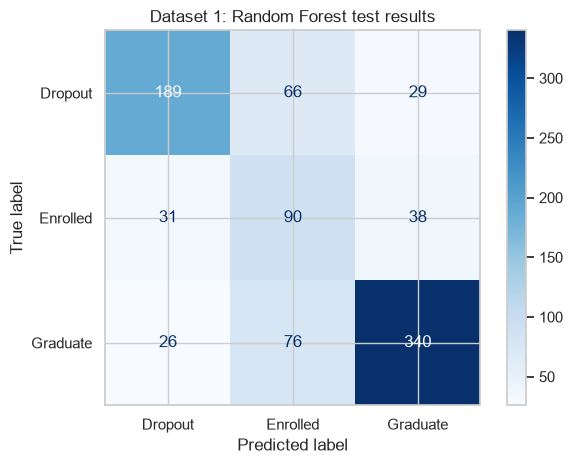

Dataset 1 classification report:


,precision,recall,f1-score,support
Dropout,0.7683,0.6655,0.7132,284.0000
Enrolled,0.3879,0.5660,0.4604,159.0000
Graduate,0.8354,0.7692,0.8009,442.0000
accuracy,0.6994,0.6994,0.6994,0.6994
macro avg,0.6639,0.6669,0.6582,885.0000
weighted avg,0.7335,0.6994,0.7116,885.0000


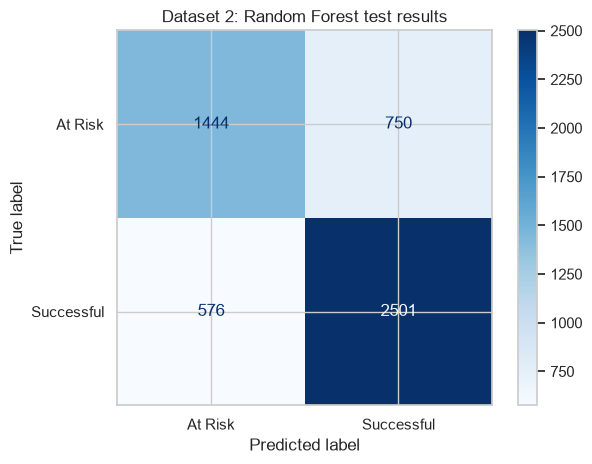

Dataset 2 classification report:


,precision,recall,f1-score,support
At Risk,0.7149,0.6582,0.6853,2194.0000
Successful,0.7693,0.8128,0.7905,3077.0000
accuracy,0.7484,0.7484,0.7484,0.7484
macro avg,0.7421,0.7355,0.7379,5271.0000
weighted avg,0.7466,0.7484,0.7467,5271.0000


Final test results:


,dataset,model,accuracy,balanced_accuracy,macro_f1,focus_class,focus_precision,focus_recall,focus_f1
0,Dataset 1,Random Forest,0.6994,0.6669,0.6582,Dropout,0.7683,0.6655,0.7132
1,Dataset 2,Random Forest,0.7484,0.7355,0.7379,At Risk,0.7149,0.6582,0.6853


In [19]:
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)


# Create folders for report outputs.
figures_dir = Path("results/figures")
metrics_dir = Path("results/metrics")

figures_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)


def train_final_model(X_train, y_train, preprocessor):
    """Train the selected Random Forest using all training records."""

    final_preprocessor = clone(preprocessor)
    final_preprocessor.set_params(sparse_threshold=1.0)

    pipeline = Pipeline([
        ("preprocessing", final_preprocessor),
        ("classifier", clone(models["Random Forest"]))
    ])

    pipeline.fit(X_train, y_train)
    return pipeline


def evaluate_final_model(
    model,
    X_test,
    y_test,
    focus_class,
    class_order,
    dataset_name,
    figure_filename
):
    """Evaluate the final model without modifying the test data."""

    predictions = model.predict(X_test)

    results = {
        "dataset": dataset_name,
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "macro_f1": f1_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "focus_class": focus_class,
        "focus_precision": precision_score(
            y_test,
            predictions,
            labels=[focus_class],
            average="macro",
            zero_division=0
        ),
        "focus_recall": recall_score(
            y_test,
            predictions,
            labels=[focus_class],
            average="macro",
            zero_division=0
        ),
        "focus_f1": f1_score(
            y_test,
            predictions,
            labels=[focus_class],
            average="macro",
            zero_division=0
        )
    }

    # Produce class-level evidence for the written discussion.
    report = pd.DataFrame(
        classification_report(
            y_test,
            predictions,
            labels=class_order,
            output_dict=True,
            zero_division=0
        )
    ).transpose()

    # The confusion matrix shows which classes the model confuses.
    display = ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=class_order,
        cmap="Blues",
        values_format="d"
    )

    display.ax_.set_title(f"{dataset_name}: Random Forest test results")
    plt.tight_layout()
    plt.savefig(figures_dir / figure_filename, dpi=300, bbox_inches="tight")
    plt.show()

    return results, report


# Train the selected model for Dataset 1.
dropout_final_model = train_final_model(
    X_dropout_train,
    y_dropout_train,
    dropout_preprocessor
)

dropout_test_results, dropout_report = evaluate_final_model(
    dropout_final_model,
    X_dropout_test,
    y_dropout_test,
    focus_class="Dropout",
    class_order=["Dropout", "Enrolled", "Graduate"],
    dataset_name="Dataset 1",
    figure_filename="dataset1_confusion_matrix.png"
)

print("Dataset 1 classification report:")
display(dropout_report.round(4))


# Train the selected model for Dataset 2.
oulad_final_model = train_final_model(
    X_oulad_train,
    y_oulad_train,
    oulad_preprocessor
)

oulad_test_results, oulad_report = evaluate_final_model(
    oulad_final_model,
    X_oulad_test,
    y_oulad_test,
    focus_class="At Risk",
    class_order=["At Risk", "Successful"],
    dataset_name="Dataset 2",
    figure_filename="dataset2_confusion_matrix.png"
)

print("Dataset 2 classification report:")
display(oulad_report.round(4))


# Combine and save the main test metrics.
final_test_results = pd.DataFrame([
    dropout_test_results,
    oulad_test_results
]).round(4)

print("Final test results:")
display(final_test_results)

final_test_results.to_csv(
    metrics_dir / "final_test_results.csv",
    index=False
)

dropout_report.to_csv(
    metrics_dir / "dataset1_classification_report.csv"
)

oulad_report.to_csv(
    metrics_dir / "dataset2_classification_report.csv"
)

## Feature importance

Random Forest feature importance is examined to identify which student,
enrolment, assessment and engagement variables contributed most strongly to
the predictions. Importance indicates predictive contribution, not causation.

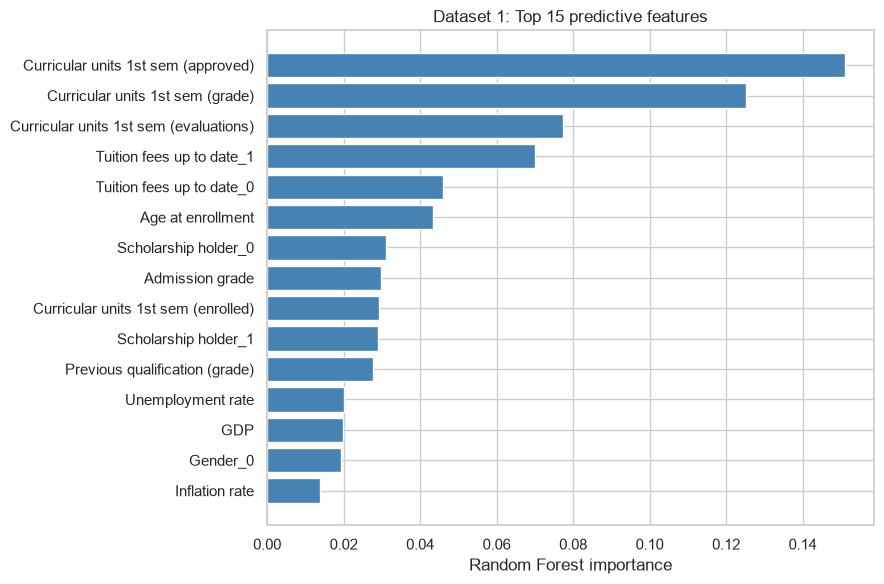

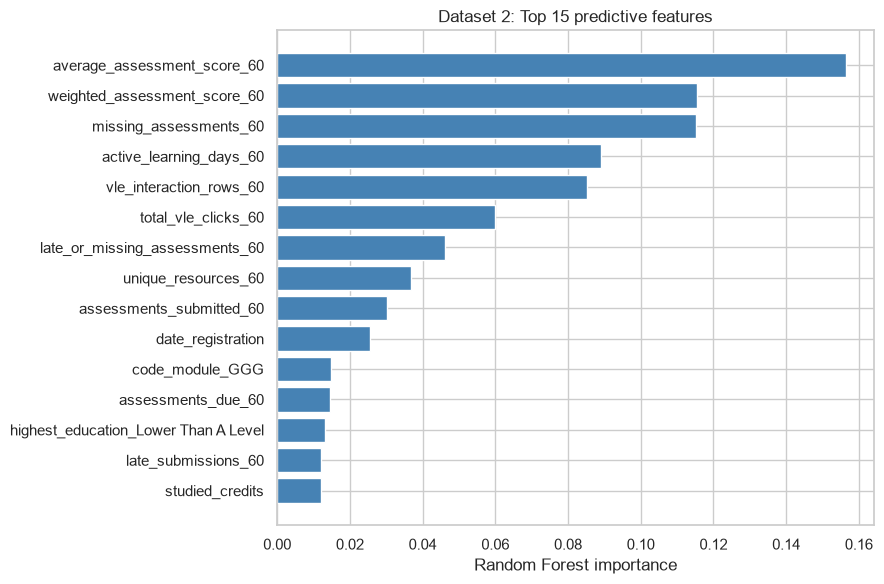

Dataset 1 most important features:


,feature,importance
0,Curricular units 1st sem (approved),0.1511
1,Curricular units 1st sem (grade),0.1252
2,Curricular units 1st sem (evaluations),0.0773
3,Tuition fees up to date_1,0.0700
4,Tuition fees up to date_0,0.0459
5,Age at enrollment,0.0433
6,Scholarship holder_0,0.0312
7,Admission grade,0.0298
8,Curricular units 1st sem (enrolled),0.0293
9,Scholarship holder_1,0.0290


Dataset 2 most important features:


,feature,importance
0,average_assessment_score_60,0.1563
1,weighted_assessment_score_60,0.1155
2,missing_assessments_60,0.1152
3,active_learning_days_60,0.0891
4,vle_interaction_rows_60,0.0851
5,total_vle_clicks_60,0.0599
6,late_or_missing_assessments_60,0.0462
7,unique_resources_60,0.0369
8,assessments_submitted_60,0.0303
9,date_registration,0.0255


In [20]:
def extract_feature_importance(model, dataset_name, filename):
    """Extract and plot the 15 most important Random Forest features."""

    preprocessor = model.named_steps["preprocessing"]
    classifier = model.named_steps["classifier"]

    # Obtain the names created by numerical processing and one-hot encoding.
    feature_names = preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.feature_importances_
    })

    # Remove pipeline prefixes to make the labels easier to read.
    importance_df["feature"] = (
        importance_df["feature"]
        .str.replace("categorical__", "", regex=False)
        .str.replace("numerical__", "", regex=False)
    )

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    top_features = importance_df.head(15).sort_values("importance")

    plt.figure(figsize=(9, 6))
    plt.barh(
        top_features["feature"],
        top_features["importance"],
        color="steelblue"
    )
    plt.xlabel("Random Forest importance")
    plt.title(f"{dataset_name}: Top 15 predictive features")
    plt.tight_layout()
    plt.savefig(
        figures_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return importance_df


dropout_feature_importance = extract_feature_importance(
    dropout_final_model,
    "Dataset 1",
    "dataset1_feature_importance.png"
)

oulad_feature_importance = extract_feature_importance(
    oulad_final_model,
    "Dataset 2",
    "dataset2_feature_importance.png"
)

print("Dataset 1 most important features:")
display(dropout_feature_importance.head(15).round(4))

print("Dataset 2 most important features:")
display(oulad_feature_importance.head(15).round(4))


# Save the complete importance tables as reproducible evidence.
dropout_feature_importance.to_csv(
    metrics_dir / "dataset1_feature_importance.csv",
    index=False
)

oulad_feature_importance.to_csv(
    metrics_dir / "dataset2_feature_importance.csv",
    index=False
)